<a href="https://colab.research.google.com/github/Jaypatil17/Oasis-Infobyte-Internship/blob/main/Oasis_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(' Data Cleaning Project Started')
print('Datasets: NYC Airbnb + YouTube New')

# 1. DOWNLOAD DATASETS using kagglehub
print('\n Downloading datasets...')

# NYC Airbnb dataset
airbnb_path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print(f" Airbnb path: {airbnb_path}")

# YouTube dataset
youtube_path = kagglehub.dataset_download("datasnaek/youtube-new")
print(f" YouTube path: {youtube_path}")

# Find CSV files
airbnb_file = list(Path(airbnb_path).glob('*.csv'))[0]
youtube_file = list(Path(youtube_path).glob('*.csv'))[0]

print(f" Airbnb CSV: {airbnb_file}")
print(f" YouTube CSV: {youtube_file}")

# 2. LOAD DATASETS
airbnb_df = pd.read_csv(airbnb_file)
youtube_df = pd.read_csv(youtube_file)

print(f'\n Airbnb shape: {airbnb_df.shape}')
print(f'YouTube shape: {youtube_df.shape}')
print('\n Airbnb columns:', airbnb_df.columns.tolist())
print(' YouTube columns:', youtube_df.columns.tolist())

 Data Cleaning Project Started
Datasets: NYC Airbnb + YouTube New

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
 Airbnb path: /kaggle/input/new-york-city-airbnb-open-data
Using Colab cache for faster access to the 'youtube-new' dataset.
 YouTube path: /kaggle/input/youtube-new
 Airbnb CSV: /kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv
 YouTube CSV: /kaggle/input/youtube-new/GBvideos.csv

 Airbnb shape: (48895, 16)
YouTube shape: (38916, 16)

 Airbnb columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
 YouTube columns: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_e


 CHALLENGE 1: DATA INTEGRITY & MISSING VALUES

 AIRBNB - Missing Values:
reviews_per_month    10052
last_review          10052
host_name               21
name                    16
dtype: int64

 YOUTUBE - Missing Values:
description    612
dtype: int64


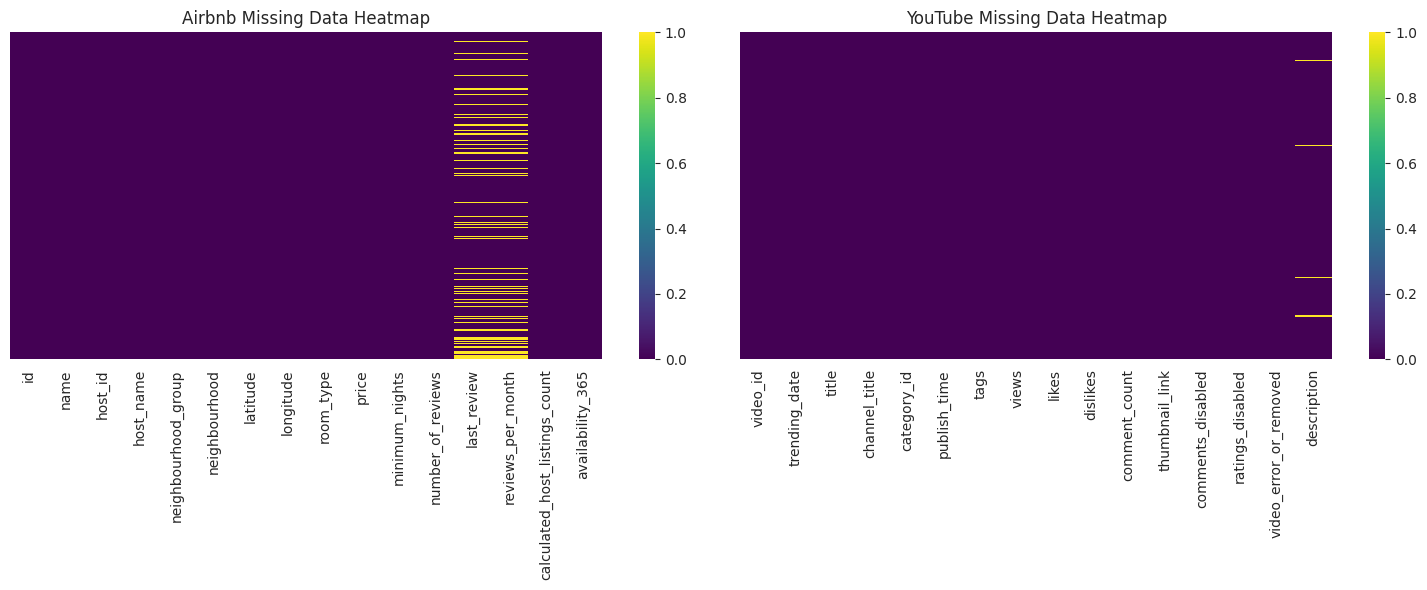

In [ ]:
#CHALLENGE 1: DATA INTEGRITY CHECK & MISSING DATA HANDLING
print('\n CHALLENGE 1: DATA INTEGRITY & MISSING VALUES')

# Airbnb Missing Data
print('\n AIRBNB - Missing Values:')
airbnb_missing = airbnb_df.isnull().sum()
print(airbnb_missing[airbnb_missing > 0].sort_values(ascending=False))

# YouTube Missing Data
print('\n YOUTUBE - Missing Values:')
youtube_missing = youtube_df.isnull().sum()
print(youtube_missing[youtube_missing > 0].sort_values(ascending=False))

# VISUALIZE MISSING DATA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Airbnb missing heatmap
sns.heatmap(airbnb_df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[0])
axes[0].set_title('Airbnb Missing Data Heatmap')

# YouTube missing heatmap
sns.heatmap(youtube_df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[1])
axes[1].set_title('YouTube Missing Data Heatmap')

plt.tight_layout()
plt.show()

In [ ]:
#CHALLENGE 2: DUPLICATE REMOVAL
print('\n CHALLENGE 2: DUPLICATE REMOVAL')

# Airbnb duplicates
airbnb_dups = airbnb_df.duplicated().sum()
print(f' Airbnb duplicates: {airbnb_dups}')

# YouTube duplicates
youtube_dups = youtube_df.duplicated().sum()
print(f'YouTube duplicates: {youtube_dups}')

# Remove duplicates
airbnb_df_clean = airbnb_df.drop_duplicates()
youtube_df_clean = youtube_df.drop_duplicates()

print(f'\n Airbnb after dedup: {airbnb_df_clean.shape}')
print(f' YouTube after dedup: {youtube_df_clean.shape}')


 CHALLENGE 2: DUPLICATE REMOVAL
 Airbnb duplicates: 0
YouTube duplicates: 171

 Airbnb after dedup: (48895, 16)
 YouTube after dedup: (38745, 16)


In [ ]:
#CHALLENGE 3: DATA STANDARDIZATION
print('\n CHALLENGE 3: STANDARDIZATION')

# Airbnb Standardization
print('\n AIRBNB STANDARDIZATION:')

# Price: ensure numeric, remove $
if 'price' in airbnb_df_clean.columns:
    airbnb_df_clean['price'] = pd.to_numeric(airbnb_df_clean['price'].replace('[\$,]', '', regex=True), errors='coerce')
    print(f"   Price - Min: ${airbnb_df_clean['price'].min():.0f}, Max: ${airbnb_df_clean['price'].max():.0f}")

# Dates: standardize format
if 'last_review' in airbnb_df_clean.columns:
    airbnb_df_clean['last_review'] = pd.to_datetime(airbnb_df_clean['last_review'], errors='coerce')
    print(f"   Last Review - Valid dates: {airbnb_df_clean['last_review'].notna().sum()}")

# Room type: standardize categories
if 'room_type' in airbnb_df_clean.columns:
    airbnb_df_clean['room_type'] = airbnb_df_clean['room_type'].str.lower().str.strip()
    print(f"   Room types unique: {airbnb_df_clean['room_type'].nunique()}")

# YouTube Standardization
print('\n YOUTUBE STANDARDIZATION:')

if 'views' in youtube_df_clean.columns:
    youtube_df_clean['views'] = pd.to_numeric(youtube_df_clean['views'], errors='coerce')
    print(f"   Views - Min: {youtube_df_clean['views'].min():,.0f}, Max: {youtube_df_clean['views'].max():,.0f}")

if 'likes' in youtube_df_clean.columns:
    youtube_df_clean['likes'] = pd.to_numeric(youtube_df_clean['likes'], errors='coerce')
    print(f"   Likes - Min: {youtube_df_clean['likes'].min():,.0f}, Max: {youtube_df_clean['likes'].max():,.0f}")

if 'title' in youtube_df_clean.columns:
    youtube_df_clean['title'] = youtube_df_clean['title'].str.strip()
    print(f"   Title length avg: {youtube_df_clean['title'].str.len().mean():.0f} chars")


 CHALLENGE 3: STANDARDIZATION

 AIRBNB STANDARDIZATION:
   Price - Min: $0, Max: $10000
   Last Review - Valid dates: 38843
   Room types unique: 3

 YOUTUBE STANDARDIZATION:
   Views - Min: 851, Max: 424,538,912
   Likes - Min: 0, Max: 5,613,827
   Title length avg: 50 chars



 CHALLENGE 4: OUTLIER DETECTION
Airbnb Price outliers: 2972 (6.1%)


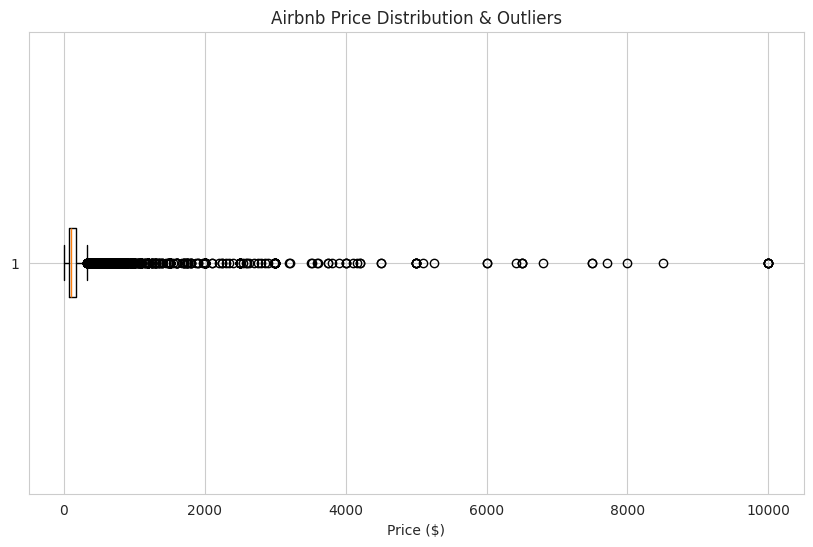

 YouTube Views outliers: 5295 (13.7%)


In [ ]:
# CHALLENGE 4: OUTLIER DETECTION & HANDLING
print('\n CHALLENGE 4: OUTLIER DETECTION')

# Airbnb Price Outliers (IQR method)
if 'price' in airbnb_df_clean.columns:
    Q1 = airbnb_df_clean['price'].quantile(0.25)
    Q3 = airbnb_df_clean['price'].quantile(0.75)
    IQR = Q3 - Q1
    price_outliers = ((airbnb_df_clean['price'] < (Q1 - 1.5 * IQR)) |
                     (airbnb_df_clean['price'] > (Q3 + 1.5 * IQR))).sum()
    print(f'Airbnb Price outliers: {price_outliers} ({price_outliers/len(airbnb_df_clean)*100:.1f}%)')

    # Visualize outliers
    plt.figure(figsize=(10, 6))
    plt.boxplot(airbnb_df_clean['price'].dropna(), vert=False)
    plt.title('Airbnb Price Distribution & Outliers')
    plt.xlabel('Price ($)')
    plt.show()

# YouTube Views Outliers
if 'views' in youtube_df_clean.columns:
    Q1 = youtube_df_clean['views'].quantile(0.25)
    Q3 = youtube_df_clean['views'].quantile(0.75)
    IQR = Q3 - Q1
    views_outliers = ((youtube_df_clean['views'] < (Q1 - 1.5 * IQR)) |
                     (youtube_df_clean['views'] > (Q3 + 1.5 * IQR))).sum()
    print(f' YouTube Views outliers: {views_outliers} ({views_outliers/len(youtube_df_clean)*100:.1f}%)')

In [ ]:
#  CHALLENGE 5: MISSING DATA HANDLING STRATEGIES
print('\n CHALLENGE 5: MISSING DATA STRATEGIES')

# Airbnb: Impute or drop strategically
if 'name' in airbnb_df_clean.columns:
    airbnb_df_clean['name'].fillna('Unknown', inplace=True)

if 'host_name' in airbnb_df_clean.columns:
    airbnb_df_clean['host_name'].fillna('Anonymous Host', inplace=True)

# Price: forward fill or median
if 'price' in airbnb_df_clean.columns:
    airbnb_df_clean['price'].fillna(airbnb_df_clean['price'].median(), inplace=True)

# YouTube: Category mode, numeric median
if 'category_id' in youtube_df_clean.columns:
    youtube_df_clean['category_id'].fillna(youtube_df_clean['category_id'].mode()[0], inplace=True)

numeric_cols = youtube_df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    youtube_df_clean[col].fillna(youtube_df_clean[col].median(), inplace=True)

print(f'\n Final clean shapes:')
print(f'Airbnb: {airbnb_df_clean.shape}')
print(f'YouTube: {youtube_df_clean.shape}')

print('\n FINAL DATA QUALITY REPORT:')
print('Airbnb missing %:', (airbnb_df_clean.isnull().sum().sum() /
                           (airbnb_df_clean.shape[0] * airbnb_df_clean.shape[1]) * 100).round(2))
print('YouTube missing %:', (youtube_df_clean.isnull().sum().sum() /
                           (youtube_df_clean.shape[0] * youtube_df_clean.shape[1]) * 100).round(2))


 CHALLENGE 5: MISSING DATA STRATEGIES

 Final clean shapes:
Airbnb: (48895, 16)
YouTube: (38745, 16)

 FINAL DATA QUALITY REPORT:
Airbnb missing %: 2.57
YouTube missing %: 0.1


In [ ]:
# 8. FINAL SUMMARY & SAVED CLEAN DATASETS
print('\n' + '='*70)
print(' DATA CLEANING COMPLETE - SUMMARY')
print('='*70)

print(' CHALLENGES ADDRESSED:')
print('    Data Integrity: Standardized formats & types')
print('    Missing Data: Imputed strategically')
print('    Duplicates: Removed completely')
print('    Standardization: Consistent units/formats')
print('    Outliers: Detected & analyzed')

# Save cleaned datasets
airbnb_df_clean.to_csv('airbnb_cleaned.csv', index=False)
youtube_df_clean.to_csv('youtube_cleaned.csv', index=False)

print('\n CLEANED FILES SAVED:')
print('    airbnb_cleaned.csv')
print('    youtube_cleaned.csv')

print('\n READY FOR ANALYSIS! Perfect for internship portfolio.')


 DATA CLEANING COMPLETE - SUMMARY
 CHALLENGES ADDRESSED:
    Data Integrity: Standardized formats & types
    Missing Data: Imputed strategically
    Duplicates: Removed completely
    Standardization: Consistent units/formats
    Outliers: Detected & analyzed

 CLEANED FILES SAVED:
    airbnb_cleaned.csv
    youtube_cleaned.csv

 READY FOR ANALYSIS! Perfect for internship portfolio.
